<img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:150px">

<hr style="border-width:2px;border-color:#75DFC1">
<h1><center>Masterclass — Interprétabilité des modèles</center></h1>
<hr style="border-width:2px;border-color:#75DFC1">

## Objectifs pédagogiques

À la fin de ce notebook, vous devriez être capable de :

1. **Expliquer** pourquoi l'interprétabilité est importante dans les vrais projets de ML — pas seulement pour la performance, mais aussi pour la confiance, l'équité et la réglementation
2. **Utiliser les techniques traditionnelles** telles que la feature importance, les coefficients et l'ACP (PCA), tout en reconnaissant leurs limites
3. **Appliquer SHAP** aux modèles basés sur des arbres afin d'obtenir des explications à la fois globales et locales
4. **Lire et interpréter** avec assurance les summary plots, dependence plots et force plots de SHAP
5. **Étendre SHAP** à un cadre de classification de texte multi-classes
6. **Mener une analyse indépendante** sur un nouveau jeu de données

## Comment utiliser ce notebook

- **Exécutez un bloc, puis faites une pause** : après chaque graphique, essayez de répondre à la question posée avant de lire l'explication
- **Gardez deux questions en tête** : *le modèle est-il efficace ?* et *son raisonnement est-il acceptable ?*
- **Traitez avec précaution les variables liées aux personnes** : des variables comme l'âge, le genre ou la situation matrimoniale reflètent des motifs présents dans les données ; elles ne définissent pas la valeur ni la capacité d'une personne
- **Lisez en vous appuyant sur les visuels** : le notebook est conçu pour être suivi avec les graphiques, pas seulement avec le texte

## Feuille de route

| Partie | Question à laquelle nous répondrons | Données | Visuel principal |
|------|------------------------|------|-------------|
| **Partie 1** | Jusqu'où peut-on aller avec l'interprétabilité classique ? | Recensement (tabulaire) | Arbre, coefficients, PCA, SHAP |
| **Partie 2** | La même logique fonctionne-t-elle sur du texte et en multi-classes ? | Émotions (texte) | Force plots multi-classes |
| **Partie 3** | Pouvez-vous mener le workflow complet seul·e ? | Au choix | Votre propre analyse SHAP |

## Pourquoi l'interprétabilité est importante : un exemple concret

Imaginez qu'une équipe construise un classifieur d'images loup vs chien. Il atteint **98 % d'accuracy** sur l'ensemble de test. Impressionnant — faut-il le déployer ?

Pas encore.

<center><img src="https://datascientest.fr/train/assets/chien-loup.jpg" style="height:260px"></center>

Une méthode d'interprétation révèle que le modèle **ne regarde pas du tout les animaux**. Il utilise à la place les pixels de l'arrière-plan. Les loups apparaissent dans des forêts enneigées ; les chiens apparaissent en intérieur. Le modèle a appris la scène, pas l'animal.

<center><img src="https://datascientest.fr/train/assets/chien-loup-2.jpg" style="height:260px"></center>

C'est l'idée centrale de ce notebook : **une accuracy élevée ne garantit pas un raisonnement solide**.

## Les enjeux dans le monde réel

Passons maintenant des images à une décision à fort enjeu. Une banque utilise un modèle de ML pour appuyer ses décisions d'éligibilité à un prêt. Le modèle est précis, mais lorsqu'un client est refusé, le chargé de prêt ne peut pas expliquer pourquoi. En France et dans l'UE, l'explicabilité n'est pas seulement une préoccupation pratique ; elle peut aussi être une obligation légale au titre du RGPD. Le travail d'un·e Data Scientist consiste donc non seulement à entraîner un modèle performant, mais aussi à rendre son raisonnement compréhensible par les personnes concernées.

## Deux dimensions de l'interprétabilité

**Portée** — *Quel niveau l'explication cible-t-elle ?*
- **Globale** : comment le modèle se comporte-t-il dans son ensemble ? Quelles variables comptent le plus sur toutes les prédictions ?
- **Locale** : pourquoi le modèle a-t-il fait *cette prédiction précise* pour *cette personne précise* ?

**Type de méthode** — *Quand l'explication est-elle générée ?*
- **Intrinsèque** : intégrée au modèle lui-même, comme pour les arbres de décision ou les coefficients de modèles linéaires
- **Post hoc** : appliquée après l'entraînement pour expliquer un modèle boîte noire, comme avec SHAP ou LIME

Ce notebook passe progressivement des méthodes intrinsèques aux méthodes post hoc. Nous commençons par des modèles simples, faciles à inspecter, puis passons à un modèle plus puissant dont le raisonnement doit être reconstruit après l'entraînement.

Commençons par des données de recensement, dont les variables sont faciles à lire et à discuter.

* (a) Importez les packages nécessaires.


In [1]:
# ── Manipulation de données ────────────────────────────────────────────────────
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Prétraitement et sélection de modèle ──────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Modèles ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import xgboost as xgb  # gradient boosting — notre modèle « boîte noire » à expliquer

# ── Interprétabilité ───────────────────────────────────────────────────────────
import shap             # SHapley Additive exPlanations — l'outil principal de ce notebook

from IPython.display import display
pd.set_option('display.max_columns', None)
%matplotlib inline


/Users/seb/Documents/interpretabiliy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Partie 1 — Classification binaire sur données tabulaires (Recensement)

### Partie 1a — Préparation des données et modèles de référence

Nous commençons par un jeu de données tabulaire car il offre le point d'entrée le plus intuitif vers l'interprétabilité.

**Jeu de données** : données du recensement américain — prédire si un individu gagne plus ou moins de 50 000 $/an.

**Variables** : âge, niveau d'éducation, situation matrimoniale, profession, genre, gain/perte en capital, heures travaillées par semaine, pays d'origine.

**Pourquoi ce jeu de données ?** Les variables sont lisibles par un humain. Lorsqu'un modèle met en avant `marital-status` ou `hours-per-week`, on peut immédiatement se demander si le motif a du sens et s'il doit être utilisé avec précaution.

**Ce à quoi il faut faire attention dans cette partie :**
- comment le prétraitement transforme les données brutes en entrées prêtes pour le modèle
- comment la performance évolue lorsque les modèles deviennent plus flexibles
- comment la qualité de l'explication dépend de la famille de modèles

* (b) Chargez `census_data_v1.csv` dans un DataFrame.


In [2]:
# Insérez votre code ici


In [3]:
df = pd.read_csv('census_data_v1.csv')


* (c) Nous allons jeter un rapide coup d'œil au jeu de données, ainsi qu'à la distribution de la variable cible.


In [4]:
# Insérez votre code ici


<class 'pandas.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              45222 non-null  int64
 1   workclass        45222 non-null  str  
 2   educational-num  45222 non-null  int64
 3   marital-status   45222 non-null  str  
 4   occupation       45222 non-null  str  
 5   gender           45222 non-null  str  
 6   capital-gain     45222 non-null  int64
 7   capital-loss     45222 non-null  int64
 8   hours-per-week   45222 non-null  int64
 9   native-country   45222 non-null  str  
 10  income           45222 non-null  str  
dtypes: int64(5), str(6)
memory usage: 3.8 MB


None

,age,workclass,educational-num,marital-status,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Male,0,0,40,Canada&USA,<=50K
1,38,Private,9,Married,Farming-fishing,Male,0,0,50,Canada&USA,<=50K
2,28,Local-gov,12,Married,Protective-serv,Male,0,0,40,Canada&USA,>50K
3,44,Private,10,Married,Machine-op-inspct,Male,7688,0,40,Canada&USA,>50K
4,34,Private,6,Never-married,Other-service,Male,0,0,30,Canada&USA,<=50K


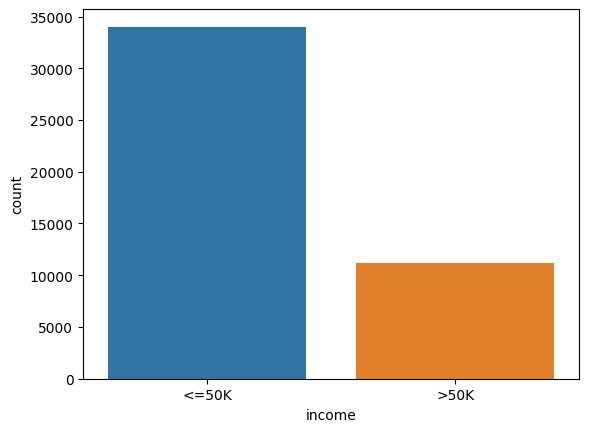

In [5]:
# Affichage des informations du jeu de données
display(df.info())

# Affichage des 5 premières lignes du jeu de données
display(df.head())

# Affichage de la distribution de la variable cible
sns.countplot(x="income", data=df, hue="income");


**Ce que ce graphique montre dans cette exécution**

La distribution des classes est clairement déséquilibrée : le groupe `<=50K` est bien plus important que le groupe `>50K`, environ trois fois plus grand dans le countplot intégré.

Cela compte pour deux raisons :
- l'accuracy seule peut être trompeuse sur ce jeu de données
- un découpage stratifié est utile pour que l'entraînement et le test conservent un ratio de classes similaire

* (d) Vérifiez la présence de valeurs manquantes dans le jeu de données. Puis séparez les variables explicatives (features) de la variable cible `income`.


In [6]:
# Insérez votre code ici


In [7]:
# Séparation des données en variables explicatives et variable cible
print(df.isna().sum())
X = df.drop(columns='income')
# ou X = df.drop('income', axis=1)
y = df['income']


age                0
workclass          0
educational-num    0
marital-status     0
occupation         0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


* (e) Divisez les données en un ensemble d'entraînement et un ensemble de test.


In [8]:
# Insérez votre code ici


In [9]:
X = df.drop(columns='income')
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80 % entraînement / 20 % test — split standard pour cette taille de jeu de données
    stratify=y,          # stratify : conserve le même ratio de classes dans train et test (important pour les cibles déséquilibrées)
    random_state=333     # graine fixe pour la reproductibilité — changez ce nombre pour tester la robustesse
)

print(f'Training set:  {X_train.shape[0]:,} rows × {X_train.shape[1]} columns')
print(f'Test set:      {X_test.shape[0]:,} rows  × {X_test.shape[1]} columns')


Training set:  36,177 rows × 10 columns
Test set:      9,045 rows  × 10 columns


> Transition : dans ce workflow, les catégories telles que `occupation` ou `marital-status` doivent être converties en nombres avant que les modèles ne puissent les utiliser. Nous allons utiliser `OneHotEncoder` pour cela, et nous allons également encoder les étiquettes cibles afin que les classifieurs puissent optimiser correctement.

* (f) Encodez les variables catégorielles de `X_train` et `X_test` à l'aide du transformateur `OneHotEncoder`. Encodez également la variable cible `y` en remplaçant les chaînes de caractères par les valeurs numériques 0 et 1.


In [10]:
# Insérez votre code ici


In [11]:
# ── Étape 1 : identifier les colonnes catégorielles vs numériques ──────────────
categorical_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numerical_cols   = X_train.select_dtypes(exclude=['object', 'string', 'category']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns  ({len(numerical_cols)}): {numerical_cols}")

# ── Étape 2 : encodage one-hot des colonnes catégorielles ─────────────────────
# sparse_output=False : renvoie un tableau dense (requis pour le concat pandas ci-dessous)
# handle_unknown='ignore' : si le test contient une catégorie absente du train, on met des zéros
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_cat_encoded = ohe.fit_transform(X_train[categorical_cols])  # fit sur le train
X_test_cat_encoded  = ohe.transform(X_test[categorical_cols])        # transform uniquement sur le test

# ── Étape 3 : récupérer les noms de colonnes après encodage ───────────────────
encoded_cat_columns = ohe.get_feature_names_out(categorical_cols)
# ex. "workclass" devient "workclass_Private", "workclass_Self-emp", etc.

# ── Étape 4 : reconstruire les DataFrames avec les bons noms de colonnes ──────
X_train_cat_df = pd.DataFrame(X_train_cat_encoded, columns=encoded_cat_columns, index=X_train.index)
X_test_cat_df  = pd.DataFrame(X_test_cat_encoded,  columns=encoded_cat_columns, index=X_test.index)

# ── Étape 5 : concaténer numérique + catégoriel encodé ─────────────────────────
# reset_index() est nécessaire car le split train/test réordonne les indices
X_train_final = pd.concat([X_train[numerical_cols].reset_index(drop=True), X_train_cat_df.reset_index(drop=True)], axis=1)
X_test_final  = pd.concat([X_test[numerical_cols].reset_index(drop=True),  X_test_cat_df.reset_index(drop=True)],  axis=1)

# ── Étape 6 : encodage de la variable cible (string → 0/1) ────────────────────
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)   # "<=50K" → 0, ">50K" → 1
y_test_encoded  = label_encoder.transform(y_test)

print()
print(f"X_train_final: {X_train_final.shape[0]:,} rows × {X_train_final.shape[1]} columns")
print(f"X_test_final:  {X_test_final.shape[0]:,} rows × {X_test_final.shape[1]} columns")
print(f"Classes: {label_encoder.classes_}  →  encoded as {[0, 1]}")


Categorical columns (5): ['workclass', 'marital-status', 'occupation', 'gender', 'native-country']
Numerical columns  (5): ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

X_train_final: 36,177 rows × 37 columns
X_test_final:  9,045 rows × 37 columns
Classes: ['<=50K' '>50K']  →  encoded as [0, 1]


### Entraînement des modèles de référence

Nous allons entraîner deux modèles volontairement simples :
- **Arbre de décision** (`max_depth=3`) : interprétable par nature, mais limité dans ce qu'il peut capturer
- **Régression logistique** : interprétable via ses coefficients, mais suppose des relations principalement linéaires

Ces modèles ne sont pas là pour « gagner » en performance. Ce sont nos **points de référence** : si un modèle plus puissant obtient de meilleurs résultats par la suite, nous voulons comprendre quelle interprétabilité nous perdons — et comment SHAP nous aide à la retrouver.

* (g) Entraînez un arbre de décision.
* (h) Évaluez-le en validation croisée (F1 + accuracy).


In [12]:
# Insérez votre code ici


In [13]:
# max_depth=3 : on garde volontairement l'arbre peu profond.
# Un arbre plus profond serait plus précis mais plus difficile à visualiser et à interpréter —
# ce qui va à l'encontre de l'objectif d'utiliser un arbre de décision pour l'interprétabilité.
# Essayez de passer à 5 ou 10 pour voir l'arbre devenir illisible.
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_final, y_train_encoded)

print("Validation Mean F1 Score: ", cross_val_score(
    tree_clf, X_train_final, y_train_encoded, cv=5, scoring='f1_macro').mean().round(3))

print("Validation Mean Accuracy: ", cross_val_score(
    tree_clf, X_train_final, y_train_encoded, cv=5, scoring='accuracy').mean().round(3))


Validation Mean F1 Score:  0.756
Validation Mean Accuracy:  0.84


* (i) Affichons le rapport de classification pour plus de détails.


In [14]:
# Insérez votre code ici


In [15]:
y_pred = tree_clf.predict(X_test_final)
print(classification_report(y_test_encoded, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.95      0.90      6803
           1       0.75      0.50      0.60      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.72      0.75      9045
weighted avg       0.83      0.84      0.82      9045



* (l) Mettons à l'échelle les variables de notre modèle avant d'entraîner notre régression logistique.


In [16]:
# Insérez votre code ici


In [17]:
# La régression logistique nécessite une mise à l'échelle des variables — les coefficients
# ne sont comparables que lorsque toutes les variables sont sur la même échelle (StandardScaler → moyenne=0, écart-type=1).
# On utilise un Pipeline pour garantir que le scaler n'est entraîné que sur les données d'entraînement (pas de fuite).
scaler = StandardScaler()
lr = LogisticRegression(
    solver='liblinear',  # efficace pour les jeux de données plus petits ; supporte la régularisation L1 et L2
    max_iter=1000        # augmentation du nombre d'itérations pour assurer la convergence
)

pipeline = Pipeline(steps=[
    ('normalization', scaler),
    ('logistic_regression', lr)
])

pipeline.fit(X_train_final, y_train_encoded)

print("Validation Mean F1 Score: ", round(cross_val_score(
    pipeline, X_train_final, y_train_encoded, cv=5, scoring='f1_macro').mean(), 3))
print("Validation Mean Accuracy: ", round(cross_val_score(
    pipeline, X_train_final, y_train_encoded, cv=5, scoring='accuracy').mean(), 3))


Validation Mean F1 Score:  0.779
Validation Mean Accuracy:  0.846


* (m) Nous entraînons le modèle de régression logistique et affichons le rapport de classification.


In [18]:
# Insérez votre code ici


In [19]:
y_pred = pipeline.predict(X_test_final)
print(classification_report(y_test_encoded, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6803
           1       0.74      0.59      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045



## Partie 1b — Techniques d'interprétabilité traditionnelles et leurs limites

À ce stade, nous avons entraîné des modèles simples. La question suivante est : **que peuvent-ils exactement nous dire sur leur propre raisonnement ?**

Nous allons examiner quatre outils classiques, puis utiliser leurs limites pour motiver l'introduction de SHAP.

| Technique | Type | Fonctionne sur | Principale limite |
|-----------|------|----------|-----------------|
| Visualisation d'arbre de décision | Intrinsèque | Arbres uniquement | Lisible seulement si l'arbre reste peu profond |
| Feature importance basée sur l'impureté | Intrinsèque | Modèles à base d'arbres | Liée à la structure apprise ; peut être instable et biaisée vers certains motifs de split |
| Coefficients de régression | Intrinsèque | Modèles linéaires uniquement | Suppose des effets principalement linéaires ; ignore les interactions |
| Biplot ACP (PCA) | Globale, post hoc | De nombreuses sorties de modèle ou espaces de variables | Projection qui perd nécessairement de l'information |

**Objectif de cette section** : comprendre ce que ces méthodes révèlent, ce qu'elles cachent, et pourquoi nous avons besoin d'un cadre d'explication plus unifié pour les modèles plus puissants.

Nous commençons par le cas le plus simple : lire l'arbre lui-même.

* (a) Affichez l'arbre de décision.


### Comment lire un arbre de décision

Un arbre de décision est une suite de questions oui/non. Vous pouvez le lire de haut en bas comme un chemin.

```text
                    [NŒUD RACINE]
                   some_feature ≤ X
                  /               \
              Vrai                Faux
          [enfant gauche]       [enfant droit]
          ...                 ...
            |                   |
          [FEUILLE]           [FEUILLE]
         classe: A           classe: B
```

**À l'intérieur de chaque boîte**

| Champ | Signification |
|-------|---------|
| `feature ≤ value` | La règle de split : aller à gauche si Vrai, à droite si Faux |
| `gini` | Impureté : 0 signifie parfaitement pur ; 0,5 signifie fortement mélangé |
| `samples` | Nombre d'exemples d'entraînement ayant atteint le nœud |
| `value: [n_0, n_1]` | Effectifs de la classe 0 et de la classe 1 à ce nœud |
| `class` | Classe majoritaire prédite à ce nœud |

**Une stratégie de lecture simple**
1. Partez du sommet et identifiez le **split racine**
2. Suivez une branche et observez la diminution du nombre d'échantillons
3. Terminez à une feuille et lisez la classe prédite

**Indice visuel sur lequel se concentrer** : la variable à la racine est le séparateur principal le plus fort dans les données.


In [20]:
# Insérez votre code ici


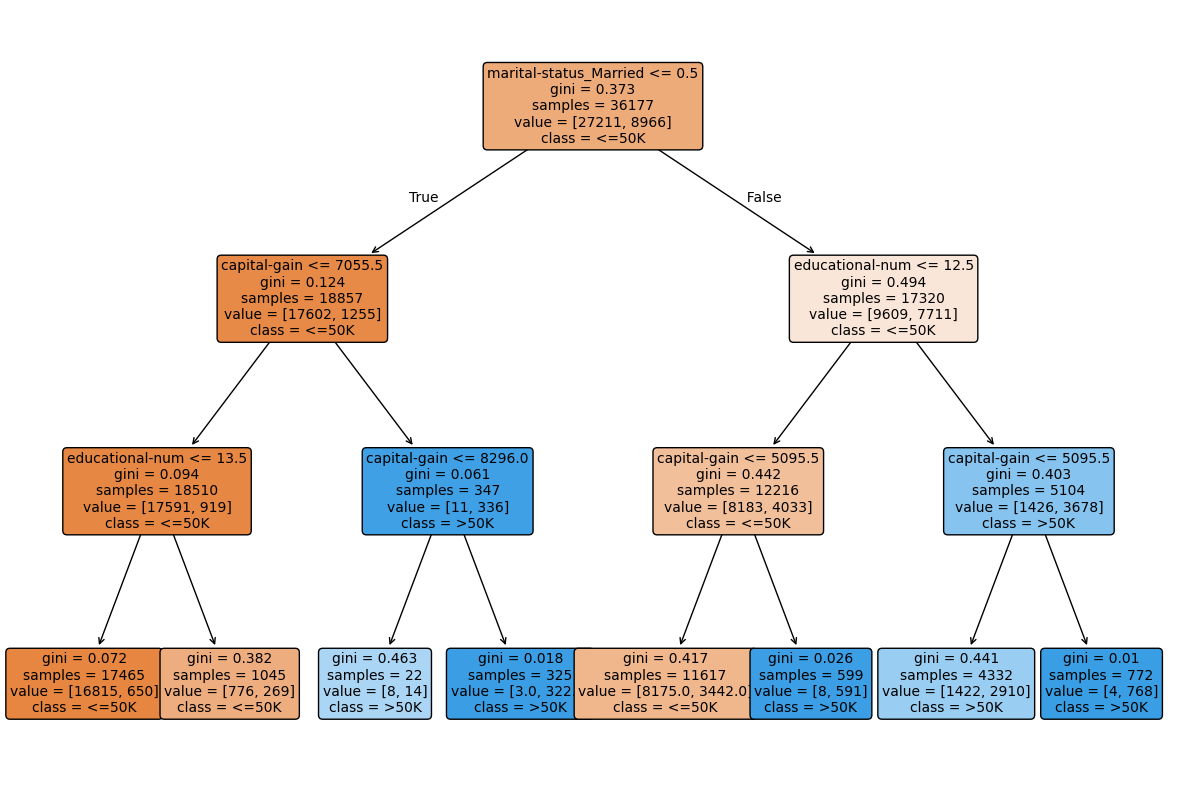

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(tree_clf, 
          feature_names=list(X_train_final.columns), 
          class_names=label_encoder.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()


### Lire l'arbre : observations clés

Appliquez maintenant les règles de lecture au graphique que vous avez généré.

**Ce que l'arbre intégré montre déjà**
1. **Split racine** : le tout premier split est `marital-status_Married <= 0.5`. Dans cet arbre appris, la situation matrimoniale est le séparateur principal le plus fort.
2. **Splits de deuxième niveau** : après cette première séparation, l'arbre s'appuie principalement sur `capital-gain` et `educational-num`. Le modèle dit donc en substance : la situation matrimoniale compte en premier, puis des signaux financiers liés au revenu et l'éducation affinent la décision.
3. **Pureté des feuilles** : plusieurs feuilles de droite ont un `gini` faible, notamment lorsque `capital-gain` est élevé. Ce sont des régions `>50K` relativement sûres.
4. **Compression du problème** : bien que le jeu de données contienne de nombreuses variables, cet arbre explique la décision avec seulement un petit sous-ensemble d'entre elles.

**Ce qu'il faut dire à voix haute quand on enseigne ce graphique**
- « Cet arbre est lisible parce qu'il est peu profond. »
- « La première question porte sur marié vs non marié. »
- « Ensuite, le modèle affine surtout la prédiction à l'aide du gain en capital et de l'éducation. »
- « Cette simplicité est utile pour l'explication, mais elle signifie aussi que le modèle ignore de nombreux autres motifs dans les données. »


> Nous pouvons lire cet arbre de haut en bas parce qu'il est volontairement peu profond. Cela nous donne quelque chose de rare en machine learning : un modèle que l'on peut inspecter presque ligne par ligne.
>
> **Ce que cet arbre nous apporte**
> - une **vue globale** des règles de décision principales
> - une **vue locale** du chemin parcouru par une personne dans l'arbre
>
> **Ce que cet arbre ne nous apporte *pas***
> - des interactions riches entre de nombreuses variables
> - une forte performance prédictive
> - une méthode transférable à des modèles non-arbres

> Une étape suivante naturelle est de résumer l'arbre appris par un classement d'importance. Dans ce cas, ce classement est la feature importance intégrée de l'arbre, basée sur l'impureté : elle résume à quel point chaque variable a contribué aux splits choisis par cet arbre précis.

* (b) Affichons les 3 variables les plus importantes du modèle `tree_clf`.


In [22]:
# Insérez votre code ici


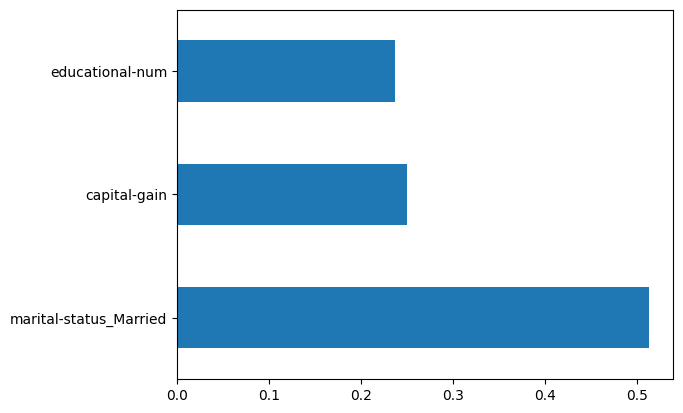

In [23]:
feat_importances = pd.Series(
    tree_clf.feature_importances_, X_train_final.columns)
feat_importances.nlargest(3).plot(kind='barh');


**Ce que ce graphique montre dans cette exécution**

Le classement d'importance intégré de l'arbre est dominé par trois variables : `marital-status_Married`, `capital-gain` et `educational-num`.

C'est utile parce que cela correspond à l'arbre que nous venons de lire. Mais c'est aussi un rappel que ce classement est spécifique à cet arbre appris : le graphique résume une structure de modèle, pas une loi universelle d'importance.

> Lisez la feature importance basée sur les arbres avec précaution : dans un arbre de décision unique, les scores d'importance intégrés sont liés à la structure apprise exacte. Un petit changement dans les données d'entraînement peut produire un arbre différent et un classement différent.
>
> Plus généralement, différentes familles de modèles utilisent différentes notions d'« importance ». Les modèles à arbres exposent souvent des importances basées sur l'impureté ; les modèles linéaires se lisent souvent via leurs coefficients ; et les méthodes indépendantes du modèle telles que l'importance par permutation peuvent être appliquées à de nombreux estimateurs à partir de leurs prédictions ou scores.
>
> Cela rend cette vue utile pour l'intuition, mais pas comme définition universelle ou totalement stable de ce qui compte.
>
> Passons ensuite à un modèle linéaire. Au lieu de lire des branches, nous allons lire des coefficients et des directions d'effet.

* (c) Pour un modèle linéaire tel que la régression logistique, une première étape courante consiste à examiner les coefficients associés à chaque variable explicative.


In [24]:
# Insérez votre code ici


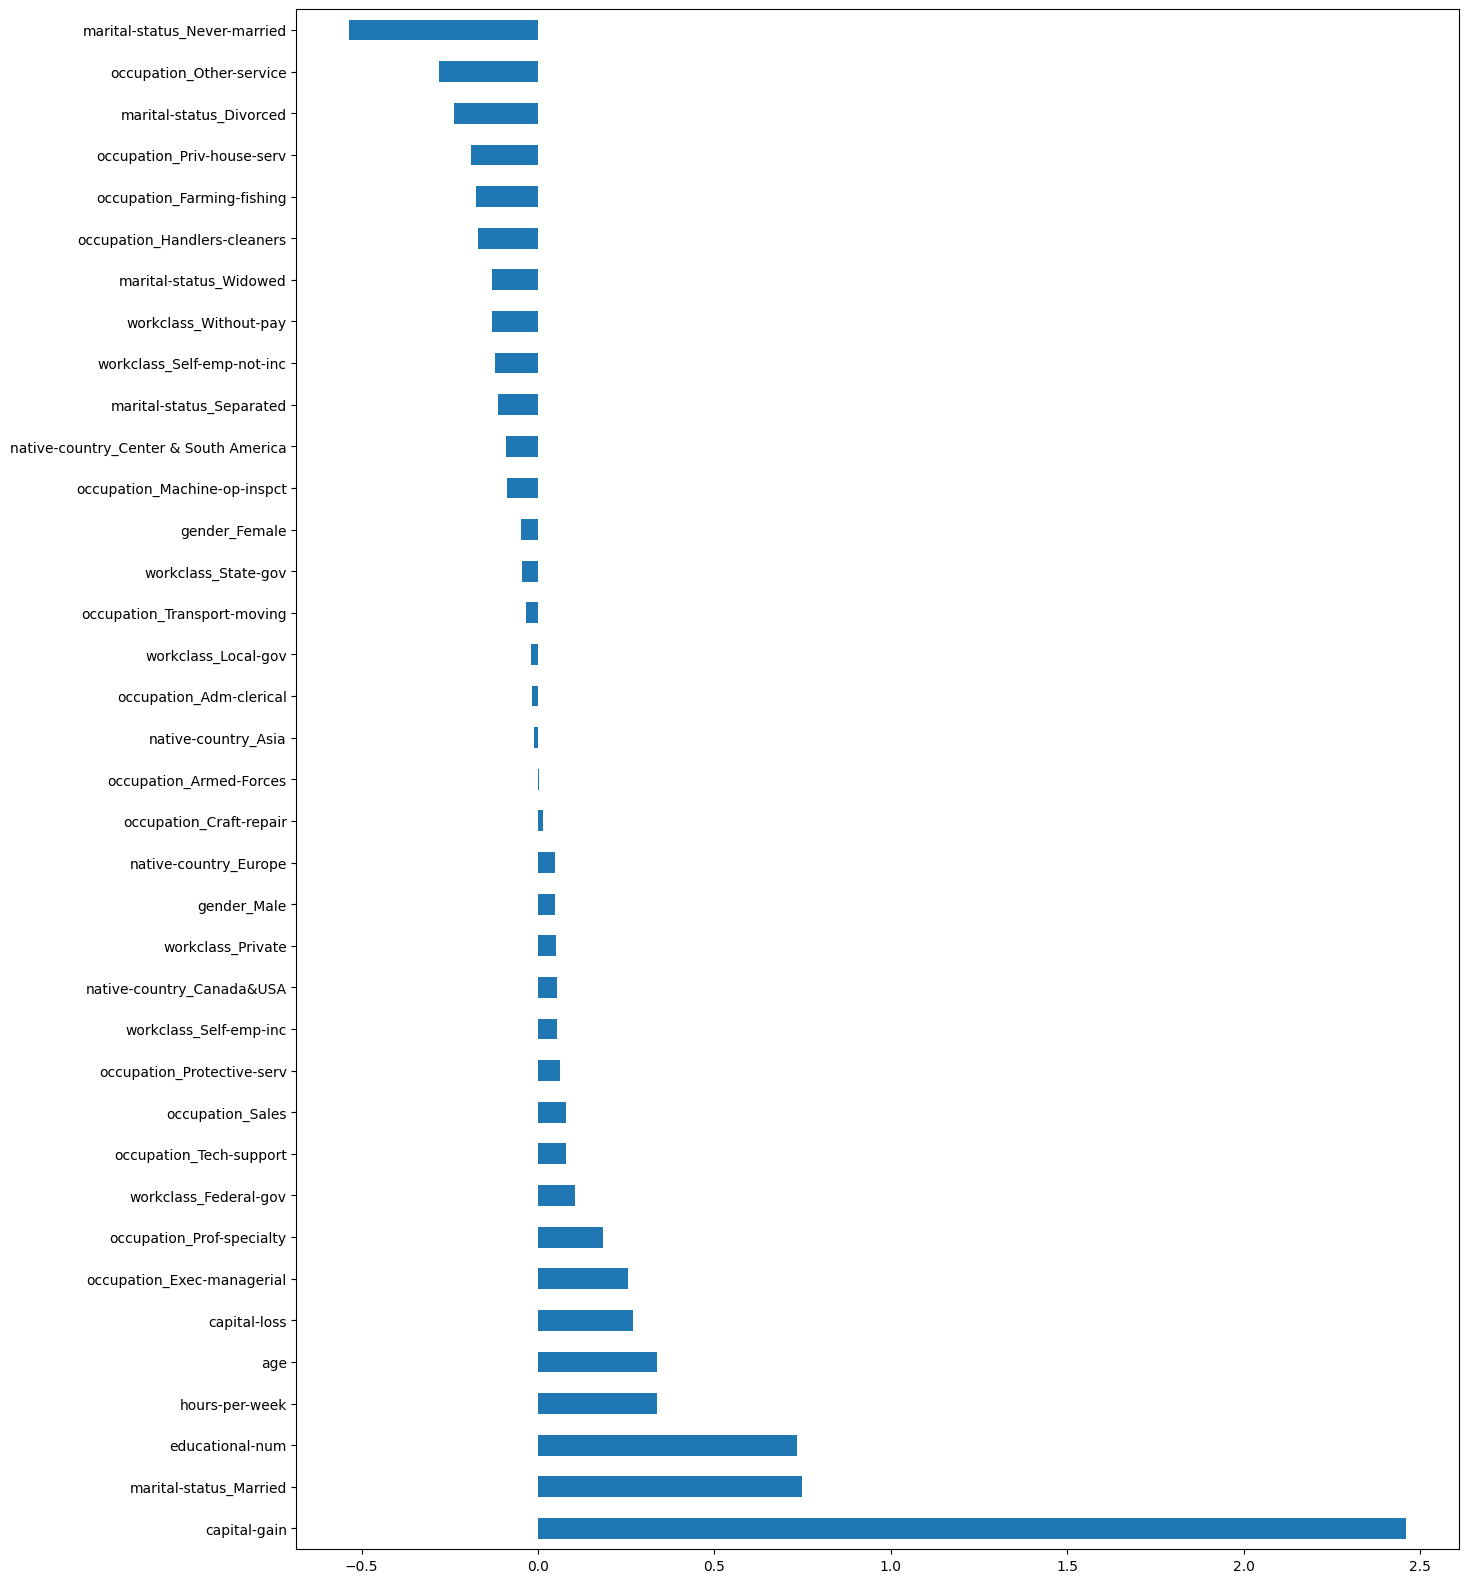

In [25]:
pd.Series(pipeline.get_params()["logistic_regression"].coef_[0], X_train_final.columns).sort_values(ascending=False).plot(kind='barh', figsize=(15,20));


> Les coefficients de la régression logistique nous indiquent la **direction** de l'association apprise par le modèle : des coefficients positifs augmentent le log-odds du modèle pour `>50K`, tandis que des coefficients négatifs le diminuent. Après mise à l'échelle, ils peuvent aussi donner une idée approximative de la taille relative des effets.
>
> Dans le graphique de coefficients intégré, le motif est assez clair :
> - `capital-gain` est de loin le coefficient positif le plus fort
> - `marital-status_Married`, `educational-num`, `hours-per-week` et `age` sont également positifs
> - `marital-status_Never-married` est fortement négatif
> - `gender_Female` est légèrement négatif, ce qui est exactement le type de motif qui mérite une discussion sur l'équité
>
> Pour bien lire les coefficients, gardez quatre mises en garde en tête :
> - **l'échelle compte** : les coefficients ne sont comparables qu'après une mise à l'échelle appropriée
> - **la corrélation compte** : des variables liées peuvent se répartir ou masquer leurs effets mutuels
> - **la taille d'un coefficient n'est pas un effet causal** : le modèle apprend des associations, pas des raisons
> - **les variables sensibles demandent de la prudence** : si le genre ou la situation matrimoniale apparaissent importants, c'est un signal pour auditer le modèle, pas pour essentialiser les personnes
>
> Les coefficients donnent un résumé plus propre qu'un arbre, mais ils ne racontent toujours pas toute l'histoire. Pour obtenir une image globale plus visuelle, nous pouvons projeter les données en deux dimensions avec une ACP.

* (d) Essayons d'analyser les résultats de notre modèle de régression logistique.


### Comment lire un biplot ACP

Un biplot ACP superpose **deux couches visuelles** sur le même graphique :
- **points** : un point par personne, projeté sur deux composantes principales
- **flèches** : une flèche par variable, indiquant la direction dans laquelle cette variable augmente

```text
          PC2 ▲
              │    ● ● ○ ○ ○
   ↑ flèche  │  ● ● ○ ○ ○
   pour feat │● ●● ○ ○ ○
    A        │  ● ○ ○ ○ ○
             └──────────────► PC1
                  → flèche pour la feature B
```

**Comment lire l'image**

| Élément | Ce qu'il indique |
|---------|-------------------|
| Couleur des points | Classe de revenu prédite |
| Direction de la flèche | Là où cette variable est élevée |
| Longueur de la flèche | À quel point cette variable structure la projection 2D |
| Points alignés avec une flèche | Individus avec des valeurs relativement élevées pour cette variable |

**Une routine visuelle rapide**
1. Cherchez une éventuelle séparation entre les deux nuages de couleur
2. Vérifiez quelles flèches pointent vers le nuage à revenu élevé
3. Repérez les flèches qui posent une question d'équité

**Indice visuel sur lequel se concentrer** : si `capital-gain` et `marital-status_Married` pointent vers la même région que le cluster `>50K`, la vue ACP est cohérente avec l'arbre et les coefficients.


In [26]:
# Insérez votre code ici


(-0.8, 0.8)

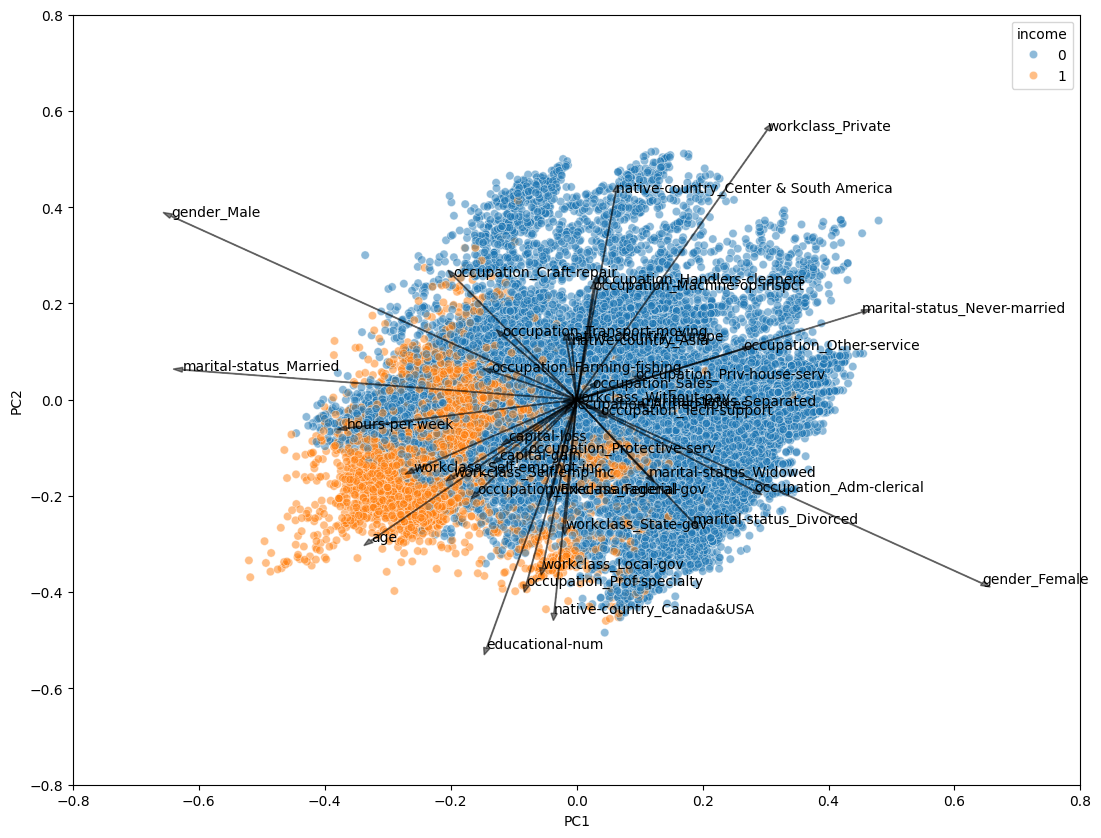

In [27]:
from sklearn.decomposition import PCA

n = X_train_final.shape[1]

pca = PCA(n_components=2)

scaler = StandardScaler()

pipeline_pca = Pipeline(steps = [('normalization', scaler),
                                 ('pca', pca)])

X_new = pipeline_pca.fit_transform(X_train_final)

coeff = pca.components_.transpose()

xs = X_new[:, 0]
ys = X_new[:, 1]
scalex = 1.0/(xs.max() - xs.min())
scaley = 1.0/(ys.max() - ys.min())


principalDf = pd.DataFrame({'PC1': xs*scalex, 'PC2': ys * scaley})

y_train_pred = pipeline.predict(X_train_final)
finalDF = pd.concat([principalDf, pd.Series(
    y_train_pred, name='income')], axis=1)


plt.figure(figsize=(13, 10))

sns.scatterplot(x='PC1', y='PC2', hue='income', data=finalDF, alpha=0.5)

for i in range(n):
    plt.arrow(0, 0, coeff[i, 0]*1.5, coeff[i, 1]*1.5,
              color='k', alpha=0.5, head_width=0.01, )
    plt.text(coeff[i, 0]*1.5, coeff[i, 1] * 1.5, X_train_final.columns[i], color='k')

plt.xlim(-0.8, 0.8)
plt.ylim(-0.8, 0.8)


### Lire le biplot ACP : observations clés

Utilisez le graphique pour répondre à trois questions.

**Ce que le biplot intégré suggère**
1. **Séparation partielle** : la classe `>50K` (orange) est davantage concentrée dans la partie droite de la figure, tandis que la classe `≤50K` (bleue) est plus dispersée à gauche. La séparation n'est pas parfaite, mais elle est visible.
2. **Alignement des flèches** : `marital-status_Married`, `hours-per-week`, `age` et `educational-num` pointent globalement vers la région où les points orange sont plus denses. C'est cohérent avec les graphiques d'arbre et de coefficients.
3. **Signal de variable sensible** : `gender_Female` pointe vers la région en bas à droite, loin d'une grande partie du cluster orange. Cela n'établit pas de causalité, mais montre que le modèle appris a intégré un motif associé au genre qui mérite un audit.

**Comment raconter ce graphique**
- « La vue ACP ne prouve rien en elle-même, mais elle donne une image globale. »
- « Le groupe à revenu élevé tend à se regrouper là où pointent éducation, heures travaillées, âge et statut marié. »
- « La flèche du genre est exactement le type de signal qui doit déclencher une discussion sur l'équité. »

**À retenir** : l'ACP est excellente pour l'exploration et la communication, mais insuffisante comme méthode d'explication finale.


## Des modèles interprétables aux boîtes noires

Nous avons maintenant vu deux références interprétables :
- **Arbre de décision** : facile à visualiser, mais limité en performance et en modélisation d'interactions
- **Régression logistique** : plus compacte à résumer, mais contrainte par des hypothèses linéaires

| Modèle | Score F1 | Interprétabilité |
|-------|----------|------------------|
| Arbre de décision (profondeur 3) | ~0,75 | Lisible comme un petit ensemble de règles |
| Régression logistique | ~0,78 | Coefficients directement inspectables |
| XGBoost (ensuite) | ~0,81 | Pas directement inspectable comme un objet unique |

Cela conduit à un compromis courant dans le monde réel. À mesure que la performance s'améliore, la lisibilité diminue souvent.

Pourquoi passer à XGBoost ? Parce qu'il peut capturer des motifs plus riches en combinant de nombreux arbres. Mais le prix est évident : il n'y a pas un seul arbre à inspecter ni une seule table de coefficients à lire. Le raisonnement est réparti sur de nombreux arbres.

C'est précisément là que SHAP devient utile. Nous gardons le modèle plus puissant, puis reconstruisons une explication autour de ses prédictions.

## Partie 1c — Interprétation du modèle avec SHAP

Pensez à SHAP comme à une manière de répondre à une seule question de façon répétée et cohérente :

> Pour cette prédiction, dans quelle mesure chaque variable a-t-elle contribué par rapport à une ligne de base ?

Les sections suivantes passent de la sortie brute de SHAP à trois vues visuelles complémentaires : un classement global, une vue de distribution et une explication individuelle.

* (a) Entraînez le modèle XGBoost.


In [28]:
# Insérez votre code ici


In [29]:
# XGBoost avec les hyperparamètres par défaut.
# Réglages par défaut : 100 arbres (n_estimators), max_depth=6, learning_rate=0.3
# On ne fait pas de tuning ici — l'objectif est l'interprétabilité, pas la performance maximale.
# Pour un modèle de production, on lancerait un grid search ou on utiliserait optuna/hyperopt.
model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_final, y_train_encoded)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

> Faisons des prédictions avec notre modèle `XGBoost` et affichons les résultats.

* (b) Stockez les étiquettes prédites par votre modèle dans une variable appelée `xgb_pred`, et les probabilités associées dans une variable appelée `xgb_proba`. Ces probabilités seront utiles dans les étapes suivantes.

* (c) Affichez le rapport de classification de votre modèle.


In [30]:
# Insérez votre code ici


In [31]:
xgb_pred = model.predict(X_test_final)
xgb_proba = model.predict_proba(X_test_final)

print(classification_report(y_test_encoded, xgb_pred))


              precision    recall  f1-score   support

           0       0.89      0.94      0.92      6803
           1       0.78      0.66      0.72      2242

    accuracy                           0.87      9045
   macro avg       0.84      0.80      0.82      9045
weighted avg       0.86      0.87      0.87      9045



> La performance est déjà un peu meilleure que celle des références peu profondes, même sans tuning des hyperparamètres. C'est pour cela que les modèles boîte noire sont si tentants en pratique.

### SHAP en une image mentale

Pensez à SHAP comme à un **outil de décomposition de prédiction** :

```text
prédiction de ligne de base sous une distribution de référence choisie
      + contribution de la variable 1
      + contribution de la variable 2
      + ...
      = sortie du modèle pour une personne
```

Autrement dit :
- la **valeur attendue** (expected_value) est la sortie de ligne de base définie par les réglages de l'explainer et les données de fond (background)
- chaque **valeur SHAP** mesure à quel point une variable a éloigné la prédiction de cette ligne de base
- additionner toutes les valeurs SHAP à la valeur attendue reconstruit la sortie du modèle expliquée

Dans cette partie, parce que nous demandons à SHAP `model_output="probability"`, la sortie expliquée est une probabilité pour la classe positive.




---
#### 🎯 Un concept clé : les « données de fond » (background data)

Avant d'aller plus loin, il faut comprendre un ingrédient que SHAP utilise dans **presque tous ses calculs** : les **données de fond** (aussi appelées *background*, *baseline*, ou *distribution de référence*).

**Définition simple** — c'est un **jeu de données représentatif** que l'on donne à l'explainer pour qu'il sache "à quoi ressemble un individu moyen dans ma population". SHAP s'en sert pour calculer ce que le modèle **prédirait en moyenne** quand il n'a aucune information spécifique sur une personne.

**Analogie** — Imaginez que vous deviez estimer le salaire d'un inconnu. Votre meilleure estimation serait la moyenne des salaires que vous avez vus. Les **données de fond jouent exactement ce rôle** : elles définissent la "réponse par défaut" du modèle avant toute variable.

**Concrètement**, à partir des données de fond SHAP calcule :

| Quantité | Formule intuitive | Rôle |
|----------|-------------------|------|
| `expected_value` | `model.predict(background).mean()` | Point de départ de toute explication (la "baseline") |
| Valeurs SHAP | contribution de chaque variable | Ce qui éloigne l'individu de cette baseline |

Et la **propriété additive fondamentale** s'écrit :

$$
\underbrace{f(x)}_{\text{prédiction pour un individu}} = \underbrace{\mathbb{E}[f(X_{\text{bg}})]}_{\texttt{expected\_value}} + \sum_{j} \underbrace{\phi_j(x)}_{\text{SHAP de la variable } j}
$$

**Choix du background en pratique**

- **Tout `X_train`** → le plus représentatif, mais peut être lent si `X_train` est très grand. OK pour nos 37 variables Census.
- **Sous-échantillon (ex. 100 à 1000 lignes)** → compromis classique quand le dataset est gros (c'est ce qu'on utilisera en Partie 3 pour le texte vectorisé).
- **`shap.sample(X_train, 100)`** → tirage aléatoire, utile si `X_train` est énorme.

> ⚠️ **À retenir** : les valeurs SHAP sont **toujours relatives à un background**. Le même modèle avec un background différent donnera des valeurs SHAP différentes (la somme reste cohérente avec la prédiction, mais les attributions individuelles bougent). Ce n'est pas un bug — c'est la définition mathématique issue de la théorie des jeux coopératifs sur laquelle SHAP repose.
---

* (d) Analysons les prédictions de notre modèle avec SHAP.


In [32]:
# Insérez votre code ici


In [33]:
# TreeExplainer est en général l'explainer SHAP le plus rapide pour les modèles à base d'arbres
# tels que XGBoost, LightGBM et Random Forest.
# Pour les ensembles d'arbres standards, il utilise l'algorithme TreeSHAP, qui est bien
# plus rapide que les explainers génériques indépendants du modèle.
#
# feature_perturbation="interventional" : cela définit comment SHAP gère la dépendance
# entre variables par rapport aux données de fond fournies. C'est souvent préféré dans
# les contextes tabulaires où la dépendance entre variables compte, mais cela reste une hypothèse,
# pas une garantie d'interprétation causale.
#
# model_output="probability" : dans cet exemple binaire, nous demandons à SHAP d'expliquer
# la probabilité prédite pour la classe positive plutôt qu'un score brut.
#
# data=X_train_final : le jeu de données de référence utilisé pour définir la valeur de ligne de base.
# Utiliser les données d'entraînement comme fond est une pratique courante.

explainer = shap.TreeExplainer(
    model,
    data=X_train_final,
    feature_perturbation="interventional",
    model_output="probability"
)

# Calcul des valeurs SHAP pour l'ensemble de test.
# Résultat : une matrice de forme (n_test_samples, n_features).
# Chaque valeur indique dans quelle mesure une variable a modifié la probabilité expliquée
# pour une personne par rapport à la ligne de base définie par l'explainer.
shap_values = explainer.shap_values(X_test_final)
print(f"SHAP values shape: {shap_values.shape}  → ({X_test_final.shape[0]} test samples × {X_test_final.shape[1]} features)")


 96%|=================== | 8668/9045 [00:22<00:00]       

SHAP values shape: (9045, 37)  → (9045 test samples × 37 features)


> Dans la cellule ci-dessus, nous passons `data=X_train_final` à `TreeExplainer` : **c'est ça, notre background**.

### De la sortie de l'explainer à des données lisibles

L'explainer renvoie une matrice de valeurs SHAP :
- **lignes** = personnes de l'ensemble de test
- **colonnes** = variables
- **cellule `(i, j)`** = à quel point la variable `j` a changé la sortie expliquée du modèle pour la personne `i`

```text
                variable 1   variable 2   variable 3   ...
personne 1        +0,12        -0,03        +0,01
personne 2        -0,08        +0,10        +0,00
personne 3        +0,02        -0,01        -0,05
```

Dans cette section, une valeur SHAP positive pousse la probabilité prédite vers `>50K`, tandis qu'une valeur SHAP négative la pousse vers `≤50K`.

À ce stade, ne vous préoccupez pas de chaque nombre. Comprenez d'abord la structure. Les graphiques suivants transforment cette matrice en quelque chose de bien plus facile à lire visuellement.

* (e) Affichons les valeurs de Shapley estimées par SHAP pour chaque variable et chaque observation. Pour cela, créons un `DataFrame` contenant les valeurs de Shapley présentes dans `shap_values`.


In [34]:
# Insérez votre code ici


In [35]:
print(shap_values.shape)
df_shap = pd.DataFrame(shap_values, columns = X_train_final.columns)
df_shap.head()


(9045, 37)


,age,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,gender_Female,gender_Male,native-country_Asia,native-country_Canada&USA,native-country_Center & South America,native-country_Europe
0,-0.026125,-0.010971,-0.035090,0.004427,0.065219,-0.000547,0.003589,-0.001330,-0.000632,0.002317,-0.000989,0.0,0.000018,0.106523,0.006129,0.000303,-0.000381,0.000745,0.0,-0.000204,-0.015423,0.001300,0.002299,-0.067167,0.004009,0.000253,-0.006168,0.000582,-0.004875,-0.000690,0.002335,0.003409,0.0,0.0,0.000593,0.008164,0.0
1,-0.018125,-0.048008,0.482682,0.005570,0.024239,-0.002927,0.002520,0.002507,-0.000284,-0.103422,0.001676,0.0,0.000655,0.164407,0.012967,0.001450,-0.000358,0.000057,0.0,-0.017855,-0.007754,0.002187,0.002708,0.003318,0.008715,0.000651,-0.006269,0.000044,-0.008623,-0.000984,0.001286,-0.012993,0.0,0.0,-0.000021,0.008287,0.0
2,0.078402,-0.065145,-0.032864,0.004377,0.046755,-0.001023,0.003032,-0.001489,-0.000502,0.003143,-0.001734,0.0,0.000397,0.102273,0.006508,0.000394,-0.000417,0.000827,0.0,-0.000863,-0.013402,0.001637,0.001541,-0.069213,0.003641,0.000552,-0.005793,0.000499,-0.004858,-0.000975,0.001125,0.013630,0.0,0.0,0.000441,0.006016,0.0
3,0.010079,-0.016317,-0.044039,0.001467,-0.010042,-0.000281,-0.001410,-0.004157,0.000149,0.001516,0.001457,0.0,0.000229,-0.121632,-0.011842,0.000334,-0.000027,0.002647,0.0,0.000304,-0.005944,0.000496,0.000956,0.002804,0.001096,0.000054,-0.006040,-0.003077,-0.001673,-0.000068,0.000681,-0.004423,0.0,0.0,-0.000222,0.003102,0.0
4,0.051464,-0.018833,0.664306,0.003559,0.041045,-0.000886,0.001403,-0.000048,0.000005,-0.019681,-0.000057,0.0,-0.005677,-0.026514,0.012616,0.002614,-0.000135,0.000490,0.0,0.001580,0.023613,0.001518,0.001539,0.005388,0.005192,0.001140,-0.000734,-0.000260,-0.001406,-0.000228,0.000865,0.012947,0.0,0.0,0.000006,0.001968,0.0


### Comprendre la structure de la sortie SHAP

Le DataFrame SHAP que vous venez de créer est la sortie principale. Voici comment le lire :

| Élément | Forme | Signification |
|---------|-------|---------|
| Tableau `shap_values` | (9045, 37) | Une valeur SHAP par personne et par variable |
| Chaque **ligne** | (37,) | Toutes les contributions de variables pour une personne |
| Chaque **colonne** | (9045,) | Distribution de l'impact d'une variable sur toutes les personnes |
| **Valeur positive** | — | Cette variable a poussé la sortie expliquée au-dessus de la ligne de base |
| **Valeur négative** | — | Cette variable a poussé la sortie expliquée en dessous de la ligne de base |
| **Valeur proche de 0** | — | Cette variable a eu peu d'influence pour cette personne |

Dans cette configuration, l'`expected_value` (~0,24) est la probabilité de ligne de base pour la classe positive sous les données de fond transmises à l'explainer.

### Qu'est-ce que la valeur attendue exactement ici ?

Dans cette section binaire, SHAP explique le modèle dans l'**espace des probabilités** parce que nous avons demandé `model_output="probability"`.

L'histoire est donc :

```text
données de fond
      ↓
le modèle prédit de nombreuses probabilités pour la classe >50K
      ↓
probabilité moyenne de ligne de base  = expected_value
```

Puis, pour une personne précise :

```text
expected_value
+ contribution SHAP de age
+ contribution SHAP de capital-gain
+ contribution SHAP de marital-status
+ ...
= probabilité prédite pour cette personne
```

Cela signifie :
- `expected_value` n'est **pas** la probabilité du modèle pour un individu précis
- c'est le **point de départ partagé** utilisé pour toutes les explications locales
- la probabilité du modèle pour une personne est la **valeur finale après ajout de toutes les contributions SHAP**

Une distinction utile :
- **probabilité du modèle** = ce que `predict_proba` renvoie pour une personne
- **valeur attendue** (expected value) = la ligne de base commune
- **probabilité reconstruite par SHAP** = `expected_value + sum(valeurs SHAP pour cette personne)`

---

* (f) Affichez l'expected value.
* (g) Vérifiez : somme des valeurs SHAP pour la ligne 0 + expected value = probabilité prédite pour cette personne.


In [36]:
background_proba = model.predict_proba(X_train_final)[:, 1]

print(f"Expected value from SHAP:                 {explainer.expected_value:.4f}")
print(f"Mean predicted probability on background: {background_proba.mean():.4f}")
print()
print("These two numbers should be very close in this setup, because SHAP is explaining")
print("the positive-class probability relative to the background data passed to the explainer.")


Expected value from SHAP:                 0.2399
Mean predicted probability on background: 0.2479

These two numbers should be very close in this setup, because SHAP is explaining
the positive-class probability relative to the background data passed to the explainer.


In [37]:
# Vérification clé : les valeurs SHAP sont additives
# expected_value + somme(valeurs SHAP pour une personne) = probabilité prédite par le modèle pour cette personne
# C'est la propriété fondamentale de SHAP — si cela ne tient pas, quelque chose ne va pas.

print(f"Expected value (baseline probability):      {explainer.expected_value:.4f}")
print(f"Sum of SHAP values for person at index 0:   {shap_values[0, :].sum():.4f}")
print(f"Expected + SHAP sum:                        {shap_values[0, :].sum() + explainer.expected_value:.4f}")
print(f"XGBoost predicted probability (class 1):    {xgb_proba[0][1]:.4f}")
print()
print("✅ These two numbers should match — and they do.")


Expected value (baseline probability):      0.2399
Sum of SHAP values for person at index 0:   0.0416
Expected + SHAP sum:                        0.2816
XGBoost predicted probability (class 1):    0.2816

✅ These two numbers should match — and they do.


### Comment lire les summary plots SHAP

SHAP nous donne deux vues globales complémentaires. Lisez-les dans cet ordre.

**Vue 1 — Diagramme en barres**

```text
variable A  ████████████████  0,18
variable B  ████████████      0,12
variable C  ████████          0,08
```

Ce qu'il montre :
- chaque barre est l'**impact absolu moyen** d'une variable sur tous les échantillons de test
- des barres plus longues signifient que la variable compte davantage en moyenne
- ce graphique classe les variables, mais il ne montre **pas** la direction

**Vue 2 — Beeswarm**

```text
côté gauche = pousse vers ≤50K      côté droit = pousse vers >50K

capital-gain        bleu bleu | rouge rouge rouge rouge
marital_Married     bleu bleu | rouge rouge rouge rouge rouge
age                 bleu      | rouge rouge
```

Ce qu'il montre :
- chaque point est une personne
- la position horizontale est la valeur SHAP
- la couleur représente la valeur d'origine de la variable : valeurs faibles à une extrémité de l'échelle de couleur, valeurs élevées à l'autre
- des points empilés indiquent de nombreuses personnes avec des contributions similaires

**Un bon ordre de lecture**
1. Commencez par la variable située en haut
2. Vérifiez si les valeurs élevées sont majoritairement à gauche ou à droite
3. Comparez cette direction avec ce que l'arbre et les coefficients suggéraient précédemment

**Indice visuel sur lequel se concentrer** : un motif fort pour `capital-gain` devrait montrer un split net, avec les valeurs élevées poussant vers le côté `>50K`.

* (h) Affichez le diagramme en barres SHAP (top 10 variables).


In [38]:
# Insérez votre code ici


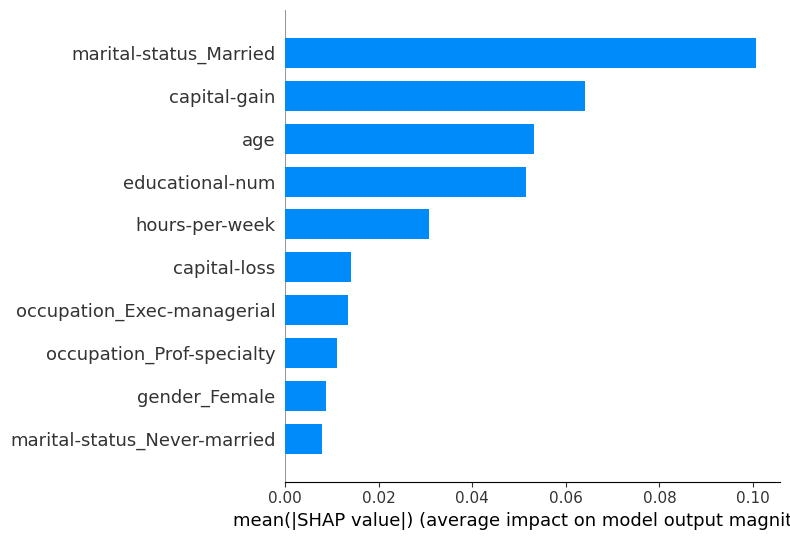

In [39]:
shap.summary_plot(shap_values, X_test_final, plot_type="bar", max_display=10)


* (i) Affichons maintenant la densité des valeurs SHAP.


In [40]:
# Insérez votre code ici


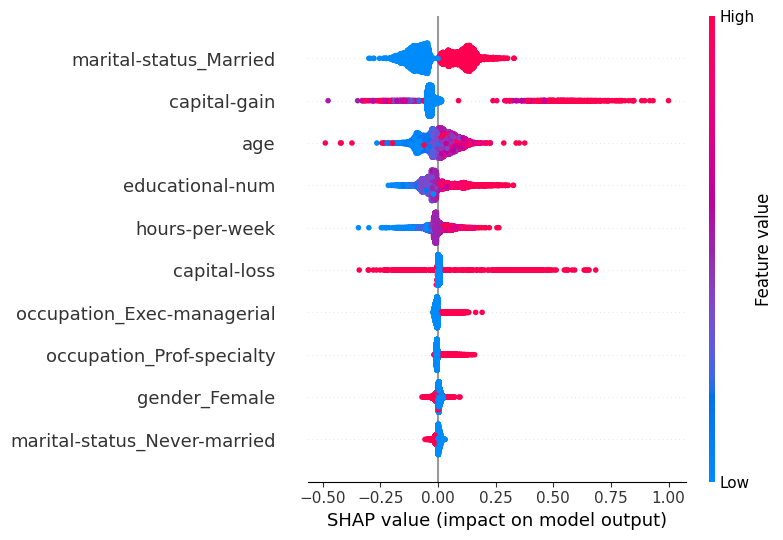

In [41]:
shap.summary_plot(shap_values, X_test_final, max_display=10)


### Lire le beeswarm : points clés

Appliquez le guide de lecture au graphique que vous venez de générer.

**Ce que le beeswarm intégré révèle déjà**
1. **Top variables** : `marital-status_Married` et `capital-gain` dominent clairement le graphique, suivies par `age`, `educational-num` et `hours-per-week`.
2. **`capital-gain`** : la plupart des points sont tassés autour de zéro, mais un plus petit groupe de valeurs élevées crée une longue queue positive à droite. C'est une variable rare mais puissante typique : pour la plupart des personnes, elle fait peu, mais pour une minorité elle pousse fortement la prédiction vers le haut.
3. **`marital-status_Married`** : les valeurs élevées se situent surtout du côté positif, tandis que les valeurs faibles se situent plutôt du côté négatif. Cela confirme à grande échelle ce que l'arbre de décision montrait à sa racine.
4. **`gender_Female`** : l'effet est plus faible que celui des variables principales, mais la distribution est légèrement décalée vers le côté négatif. Ce n'est pas le principal moteur du modèle, mais c'est assez visible pour mériter discussion.

**Un résumé pédagogique utile**
- « Le diagramme en barres nous a dit ce qui compte le plus en moyenne. »
- « Le beeswarm montre maintenant la direction, la dispersion et l'hétérogénéité. »
- « Certaines variables comptent de façon constante, d'autres ne comptent que pour un sous-ensemble d'individus. »


### Comment lire les dependence plots SHAP

Un dependence plot SHAP répond à une question très précise :

> Lorsque la valeur d'une variable change, comment sa contribution à la prédiction change-t-elle ?

```text
valeur SHAP
pour la variable X   • •
                 • •  • •        couleur = valeur d'une autre variable
      0  -----------------
                 • •   •
                 • •

                  faible  →  élevée
                 valeur de la variable X
```

**Ce qu'il faut regarder**

| Élément | Signification |
|---------|---------|
| Axe X | Valeur réelle de la variable étudiée |
| Axe Y | Valeur SHAP pour cette variable |
| Tendance croissante | Des valeurs plus élevées tendent à augmenter la prédiction |
| Forme plate | La variable a peu d'effet sur cette plage |
| Motif de couleur | Interaction avec une seconde variable |

**Ce que les graphiques actuels montrent**
- **`age`** : l'effet devient moins négatif entre le début de la vingtaine et environ la fin de la quarantaine ou la cinquantaine, puis se stabilise et devient plus bruité. Ce n'est pas un effet purement linéaire.
- **`educational-num`** : le motif est fortement monotone. Des niveaux d'éducation plus élevés sont associés à des valeurs SHAP de plus en plus positives.
- **`hours-per-week`** : il y a un seuil visible autour du temps plein. En dessous d'environ 40 heures, la contribution est souvent négative ; au-dessus, elle devient plus souvent positive.

Voilà comment passer d'une question de classement à une question de relation.

* (l) Affichez les dependence plots SHAP pour `age`, `educational-num` et `hours-per-week`.


In [42]:
# Insérez votre code ici


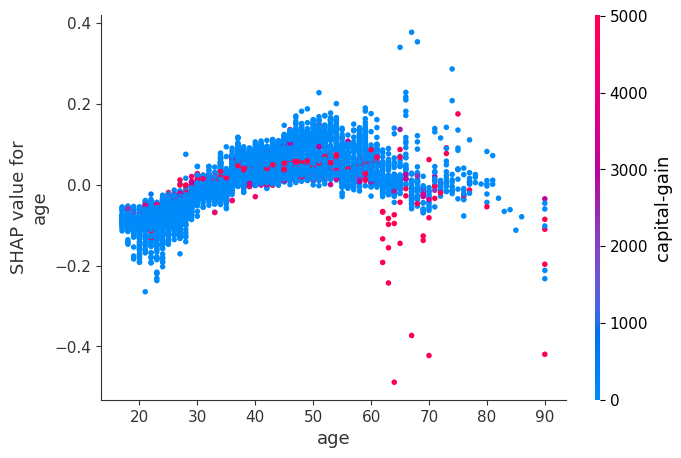

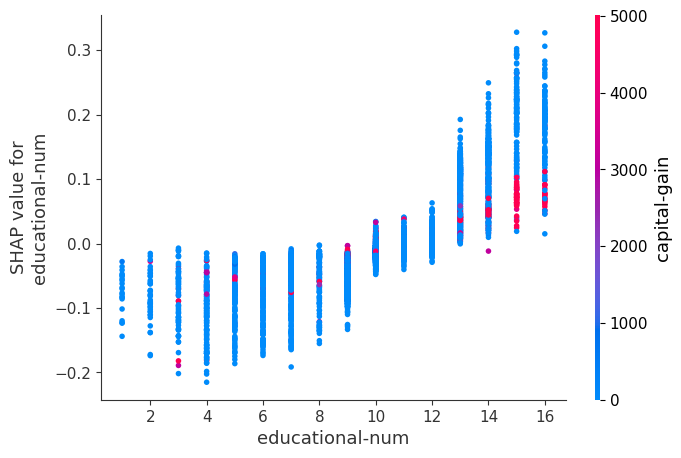

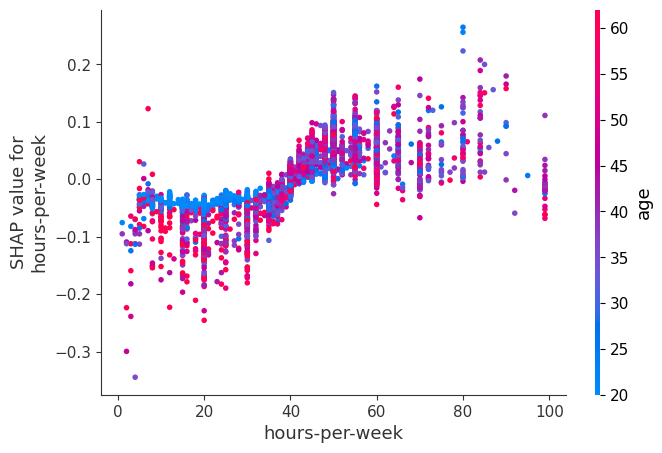

In [43]:
shap.dependence_plot("age", shap_values, X_test_final, interaction_index= "capital-gain")

shap.dependence_plot("educational-num", shap_values, X_test_final, interaction_index= "capital-gain")

shap.dependence_plot("hours-per-week", shap_values, X_test_final, interaction_index= "age")


### Comment lire un force plot SHAP

Un force plot explique **une prédiction individuelle**. Il part d'une ligne de base, puis montre quelles variables poussent la prédiction vers le bas ou vers le haut.

```text
ligne de base                prédiction finale
   |                                 |
   v                                 v
[ ligne de base ] -- bleu pousse -- rouge pousse --> f(x)
```

Vous pouvez aussi le voir comme un tir à la corde :

```text
pousse vers ≤50K   <----  prédiction de la personne  ---->   pousse vers >50K
      blocs bleus                                               blocs rouges
```

**Ce que signifie chaque élément visuel**

| Élément | Signification |
|---------|---------|
| Valeur de base | Sortie de ligne de base définie par les réglages de l'explainer et les données de fond |
| Blocs rouges | Variables poussant la sortie expliquée vers le haut |
| Blocs bleus | Variables poussant la sortie expliquée vers le bas |
| Largeur du bloc | Force de la contribution |
| `f(x)` | Sortie finale expliquée pour cette personne précise |

Dans cette section binaire, parce que nous expliquons `model_output="probability"`, la valeur de base et `f(x)` peuvent être lues comme des probabilités pour la classe positive.

**Un bon ordre de lecture**
1. Lisez d'abord la prédiction finale
2. Identifiez les blocs rouges les plus larges et les blocs bleus les plus larges
3. Traduisez-les en une explication verbale courte

* (m) Affichez le force plot pour quelques individus.


In [44]:
# Insérez votre code ici
y_pred[0]

np.int64(0)

In [45]:
shap.initjs()

display(shap.force_plot(explainer.expected_value, shap_values[0, :], X_test_final.iloc[0, :]))

shap.force_plot(explainer.expected_value, shap_values[70,:], X_test_final.iloc[70,:])


### Lire les force plots : observations clés

1. **Individu à l'index 0** : quelle est la probabilité prédite, et quelles variables dominent l'explication ?
2. **Individu à l'index 70** : en quoi cette personne diffère-t-elle de celle à l'index 0 ?
3. **Vérification de cohérence** : les explications locales correspondent-elles au classement global du beeswarm ?

**Comment utiliser ces graphiques concrètement**
- Cherchez d'abord si `marital-status_Married`, `capital-gain`, `educational-num` ou `hours-per-week` figurent parmi les blocs les plus larges.
- Si oui, c'est une confirmation locale des graphiques globaux.
- Si une variable moins bien classée devient soudainement dominante pour une personne, c'est aussi utile : cela montre comment une variable peut peu compter en moyenne, mais beaucoup pour un cas précis.

**Pourquoi les explications locales comptent** : les graphiques globaux vous disent ce qui compte en moyenne. Les force plots vous disent pourquoi le modèle a produit une décision précise pour une personne précise.

## Limites de SHAP à garder en tête

SHAP est puissant, mais il comporte encore des mises en garde importantes :

| Limite | Explication |
|------------|-------------|
| **Variables corrélées** | Si deux variables sont corrélées, le crédit peut être réparti entre elles d'une manière difficile à interpréter |
| **Coût de calcul** | `TreeExplainer` est rapide, mais les explainers indépendants du modèle peuvent être beaucoup plus lents |
| **SHAP n'est pas la causalité** | Une valeur SHAP forte reflète une association apprise, pas une preuve de cause |
| **Instabilité locale** | Des individus similaires peuvent avoir des explications locales sensiblement différentes |
| **Le choix de l'explainer compte** | Différents explainers SHAP se comportent différemment selon les familles de modèles |

Utilisez SHAP comme une façon structurée de comprendre le comportement du modèle, pas comme une vérité finale.

Nous conservons maintenant la même logique d'interprétabilité et changeons de type de données. Dans la Partie 2, les variables deviennent des mots et la tâche devient une classification multi-classes.


## Partie 2 — SHAP sur données textuelles : classification d'émotions multi-classes

La Partie 1 a établi le workflow sur des données tabulaires. La Partie 2 conserve le workflow et change l'objet expliqué.

### Qu'est-ce qui change entre la Partie 1 et la Partie 2 ?

| Aspect | Partie 1 | Partie 2 |
|--------|--------|--------|
| **Variables en entrée** | colonnes tabulaires | mots / tokens |
| **Tâche de prédiction** | classification binaire | classification à 6 classes |
| **Principale difficulté d'interprétation** | direction de l'effet | une explication par classe |
| **Espace de sortie SHAP** | probabilités | logits |

**Ce qui reste identique**
- nous entraînons toujours un `XGBClassifier`
- nous utilisons toujours `shap.TreeExplainer`
- nous posons toujours les deux mêmes questions : **qu'est-ce qui compte globalement ?** et **pourquoi cette prédiction localement ?**

**Ce qui devient plus difficile**
- les variables sont maintenant des mots et non plus des colonnes métier ou démographiques
- il y a beaucoup plus de variables
- chaque prédiction est répartie sur six classes au lieu de deux

C'est pourquoi nous ralentissons de nouveau avant de lire les sorties SHAP.

* (a) Importez le fichier `emotion.csv` et affichez les premières lignes.


In [46]:
# Insérez votre code ici


In [47]:
data = pd.read_csv('emotion.csv', index_col = 0)
data.head()


,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


> Les étiquettes de ce jeu de données correspondent à des états émotionnels exprimés dans le texte.

| Label | Émotion |
|-------|---------|
| 0 | tristesse |
| 1 | joie |
| 2 | peur |
| 3 | colère |
| 4 | surprise |
| 5 | dégoût |

> **Pourquoi CountVectorizer ?**
> Le texte ne peut pas être fourni directement à la plupart des algorithmes de ML classiques, il faut donc généralement le transformer d'abord en nombres. `CountVectorizer` suit une approche sac de mots : il compte combien de fois chaque mot apparaît dans une phrase et ignore l'ordre des mots.
> - `max_features=3000` conserve les 3000 mots les plus fréquents, ce qui réduit la dimensionnalité tout en préservant les signaux les plus courants
> - `stop_words='english'` supprime les mots très courants comme « the » ou « is » qui portent peu d'information émotionnelle
>
> **Intuition visuelle**
> ```text
> "I feel very sad today"
>        ↓
> [feel=1, sad=1, today=1, joy=0, angry=0, ...]
> ```
>
> **Limite** : le sac de mots ignore l'ordre et le contexte des mots. Par exemple, « I am not happy » et « I am happy » restent trop similaires. Des représentations plus avancées géreraient cela mieux, mais CountVectorizer reste transparent et compatible avec SHAP.

* (b) Découpez en ensembles d'entraînement/de test.
* (c) Vectorisez les textes avec `CountVectorizer`.


In [48]:
# Insérez votre code ici


In [49]:
from sklearn.feature_extraction.text import CountVectorizer

# Split train/test standard pour les données texte
# random_state=222 : graine différente de la Partie 1 pour éviter toute confusion si vous exécutez les deux
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['emotion'],
    test_size=0.2,
    random_state=222
)

# CountVectorizer : convertit chaque phrase en un vecteur de comptages de mots
# max_features=3000 : ne garder que les 3000 mots les plus fréquents (réduit le bruit, accélère l'entraînement)
#   → expérimentation : essayez 500 (moins de variables, plus rapide) ou 10000 (plus de variables, plus lent, risque d'overfit)
# stop_words='english' : supprime les mots comme "the", "is", "a" — aucun signal émotionnel
vectorizer = CountVectorizer(
    max_features=3000,
    stop_words='english'
)

# fit_transform sur TRAIN uniquement — pour éviter la fuite de données (le vocabulaire du test doit rester inconnu)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
# transform (pas fit_transform !) sur TEST — utilise le vocabulaire appris sur train
X_test_vec = vectorizer.transform(X_test).toarray()

print(f"Training matrix: {X_train_vec.shape}  (sentences × vocabulary size)")
print(f"Test matrix:     {X_test_vec.shape}")


Training matrix: (12800, 3000)  (sentences × vocabulary size)
Test matrix:     (3200, 3000)


> Maintenant que les textes sont vectorisés, nous pouvons entraîner un `XGBClassifier` multi-classes. Le modèle ne lit plus des colonnes comme `age` ou `hours-per-week` ; il lit des comptages de mots. La tâche prédictive est donc de structure similaire, mais les variables sont beaucoup plus nombreuses et beaucoup moins intuitives une à une.
>
> C'est pourquoi l'étape d'interprétation doit être particulièrement disciplinée.
>
* (d) Entraînez un modèle `XGBClassifier` sur les données vectorisées (`X_train_vect`, `y_train`). Notez que nous travaillons sur une tâche de classification multi-classes.


In [50]:
# Insérez votre code ici


In [51]:
# objective='multi:softprob' : indique à XGBoost qu'il s'agit d'un problème multi-classes
#   avec des probabilités douces (sortie : une distribution de probabilité sur toutes les classes)
# num_class=6 : il faut spécifier explicitement le nombre de classes en multi-classes
# eval_metric='mlogloss' : log-loss multi-classes (valeur par défaut de XGBoost pour multi:softprob)
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=6,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train_vec, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

* (e) Utilisez votre modèle pour prédire, pour les 20 premières observations de `X_test_vect`, la **probabilité d'appartenance à chaque classe**.
* (f) Affichez le tableau des **probabilités estimées** pour ces 20 observations.


### Comment lire la table de probabilités avant SHAP

Avant de regarder SHAP, faites une pause sur la table `predict_proba`. Elle vous apprend déjà quelque chose d'important : le modèle ne produit **pas** d'abord une étiquette. Il produit **six probabilités de classes**, puis choisit la plus grande.

Une seule ligne doit se lire comme ceci :

```text
une phrase

tristesse 0,72  ███████████████
joie      0,08  ██
peur      0,10  ██
colère    0,05  █
surprise  0,03  █
dégoût    0,02  █
```

Ce que cela signifie :
- le modèle compare six émotions possibles en même temps
- l'étiquette prédite est simplement l'**argmax** : la classe avec la probabilité la plus élevée
- les classes en deuxième position comptent toujours, car elles indiquent l'incertitude et la confusion

Une bonne habitude est de lire la table dans cet ordre :
1. identifier la classe de tête
2. identifier la deuxième classe la plus probable
3. se demander si cette confusion a un sens linguistique

Ce point compte aussi pour SHAP : dans les problèmes multi-classes, une explication est toujours liée à **une classe choisie**, pas à l'ensemble de la ligne en une seule fois.


### Important : logits vs probabilités dans SHAP multi-classes

Avant d'exécuter l'explainer SHAP, il nous faut un ajustement conceptuel.

**Dans la Partie 1** (binaire), nous avons demandé `model_output="probability"`, donc les valeurs SHAP étaient exprimées dans l'espace des probabilités.

**Dans la Partie 2** (multi-classes), dans la configuration de ce notebook, `TreeExplainer` renvoie des scores bruts de classes (logits) plutôt que des probabilités.

**Un résumé visuel compact**

```text
scores bruts du modèle pour chaque classe  --softmax-->  probabilités qui somment à 1
```

Un logit est simplement le score brut attribué par le modèle à une classe avant la transformation softmax.

$$
\text{probabilité}_k = \frac{e^{\text{logit}_k}}{\sum_{j=1}^{K} e^{\text{logit}_j}}
$$


**Qu'est-ce qui change en pratique ?**
- les valeurs SHAP ne sont plus des décalages en points de pourcentage
- les nombres exacts sont plus difficiles à lire directement
- l'information la plus importante devient la **direction** et la **taille relative** de chaque contribution

Donc, quand vous lisez un force plot multi-classes, concentrez-vous d'abord sur les mots qui poussent vers la classe et ceux qui poussent contre elle.


In [52]:
# Insérez votre code ici


### Vue humaine vs vue SHAP

Dans cette section, vous regardez la même prédiction à travers **deux lentilles différentes**.

**Lentille 1 — ce que les humains lisent habituellement**

```text
probabilités
tristesse 0,72
joie      0,08
peur      0,10
colère    0,05
surprise  0,03
dégoût    0,02
```

**Lentille 2 — ce que SHAP explique dans cette configuration**

```text
scores bruts de classes (logits)
tristesse  3,1
joie       0,7
peur       1,0
colère     0,2
surprise  -0,3
dégoût    -0,6
```

Ensuite, le softmax convertit ces scores bruts en probabilités.

L'idée clé est simple :
- les probabilités sont plus faciles à lire pour les humains
- les logits sont les scores internes utilisés par le modèle avant normalisation
- SHAP explique ces scores internes spécifiques à la classe dans cette configuration multi-classes

Le workflow multi-classes est donc :

```text
texte  ->  mots vectorisés  ->  scores bruts de classes  ->  probabilités
                                 ↑
                             SHAP explique cette couche
```


In [53]:
xgb_proba = model.predict_proba(X_test_vec[:20]).round(2)

class_labels = {0: "sadness", 1: "joy", 2: "fear", 3: "anger", 4: "surprise", 5: "disgust"}

proba_df = pd.DataFrame(xgb_proba, columns=[class_labels[i] for i in range(6)])

proba_df.head(20)


,sadness,joy,fear,anger,surprise,disgust
0,0.19,0.70,0.02,0.05,0.04,0.00
1,0.01,0.02,0.00,0.00,0.00,0.96
2,0.16,0.75,0.02,0.04,0.03,0.00
3,0.09,0.13,0.01,0.43,0.34,0.00
4,0.89,0.10,0.00,0.01,0.01,0.00
5,0.04,0.05,0.00,0.91,0.01,0.00
6,0.79,0.15,0.01,0.03,0.02,0.00
7,0.69,0.23,0.01,0.04,0.03,0.00
8,0.01,0.03,0.04,0.00,0.00,0.92
9,0.91,0.06,0.00,0.01,0.01,0.00


> Nous revenons maintenant au même workflow SHAP que dans la Partie 1 : créer un explainer, calculer les valeurs SHAP, puis inspecter la structure du résultat avant d'interpréter les graphiques.
>
> La principale différence est que nous obtiendrons un espace d'explication par classe.

* (g) Créez un `shap.TreeExplainer` à partir du modèle XGBoost entraîné.
* (h) Fournissez à l'explainer un échantillon de 1000 observations de `X_train_vect`.
* (i) Utilisez `explainer.shap_values()` pour calculer les valeurs de Shapley pour les 20 premières lignes de `X_test_vect`.
* (l) Stockez le résultat dans une variable (par exemple, `shap_values`).


In [54]:
# Insérez votre code ici


In [55]:
# Création de l'explainer SHAP pour notre modèle XGBoost multi-classes.
# Nous passons un échantillon de 1000 observations d'entraînement comme données de fond.
# Pourquoi seulement 1000 ? Calculer SHAP pour 3000 variables × 6 classes coûte cher.
# 1000 échantillons est souvent un compromis raisonnable entre temps d'exécution et stabilité.
explainer = shap.TreeExplainer(model, X_train_vec[:1000])

# Calcul des valeurs SHAP pour les 20 premières observations de test.
# Dans cette configuration / version de SHAP, `shap_values` est renvoyé comme une liste de 6 tableaux
# (un par classe), chacun de forme (20, 3000).
shap_values = explainer.shap_values(X_test_vec[:20])


> Dans cette configuration, `explainer.expected_value` contient un score brut de ligne de base par classe. Ces valeurs sont des points de référence spécifiques à chaque classe dans l'espace des logits.
>
> Un détail d'implémentation est important ici : selon la version de SHAP, les sorties multi-classes peuvent revenir sous forme :
> - d'une **liste de tableaux** avec un tableau par classe, ou
> - d'un **tableau NumPy 3D** de forme `(n_samples, n_features, n_classes)`.
>
> L'interprétation est la même, mais l'indexation change légèrement.

### Que sont exactement les expected values en multi-classes ?

Dans la section multi-classes, SHAP n'explique pas directement les probabilités. Il explique les **scores bruts de classes** du modèle.

La ligne de base est donc maintenant :

```text
données de fond
      ↓
le modèle produit 6 scores bruts de classes pour chaque texte
      ↓
score brut moyen pour chaque classe  = vecteur expected_value
```

Cela donne un score de ligne de base par classe :

```text
expected_value[0] = score de ligne de base pour la tristesse
expected_value[1] = score de ligne de base pour la joie
...
expected_value[5] = score de ligne de base pour le dégoût
```

Puis, pour un texte et une classe :

```text
score de classe pour la tristesse
= expected_value[tristesse]
+ contribution du mot 1
+ contribution du mot 2
+ ...
```

Ce n'est qu'ensuite que nous convertissons le vecteur complet de scores de classes en probabilités avec le softmax.

C'est la différence clé avec la Partie 1 :
- en **mode probabilité binaire**, SHAP s'additionne directement à une probabilité
- en **mode score brut multi-classes**, SHAP s'additionne d'abord en scores de classes, et les probabilités viennent **après le softmax**

* (m) Affichez l'`expected_value` pour chaque classe.
* (n) Confirmez qu'il y a autant d'expected values que de classes.
* (o) Affichez la forme de `shap_values` pour comprendre sa structure.


In [56]:
import numpy as np


def softmax(scores):
    scores = np.asarray(scores, dtype=float)
    scores = scores - scores.max()
    exp_scores = np.exp(scores)
    return exp_scores / exp_scores.sum()


background_mean_proba = model.predict_proba(X_train_vec[:1000]).mean(axis=0)
baseline_logits = np.asarray(explainer.expected_value, dtype=float)
baseline_proba_from_logits = softmax(baseline_logits)

comparison_df = pd.DataFrame({
    "class": [class_labels[i] for i in range(len(class_labels))],
    "expected_logit": baseline_logits,
    "softmax(expected_logit)": baseline_proba_from_logits,
    "mean predict_proba on background": background_mean_proba,
})

print("How to read this table:")
print("- `expected_logit` is what SHAP uses as the class baseline in this multiclass setup")
print("- `softmax(expected_logit)` converts those baselines into a probability vector")
print("- `mean predict_proba on background` is the average model probability vector on the same background sample")
print("- The last two columns are related, but they are not generally identical")
print("  because softmax(mean logits) != mean softmax(logits)")
print()
display(comparison_df.round(4))

sample_idx = 4
if isinstance(shap_values, list):
    reconstructed_logits = np.array([
        explainer.expected_value[class_idx] + shap_values[class_idx][sample_idx].sum()
        for class_idx in range(len(class_labels))
    ])
else:
    reconstructed_logits = np.array([
        explainer.expected_value[class_idx] + shap_values[sample_idx, :, class_idx].sum()
        for class_idx in range(len(class_labels))
    ])

reconstructed_proba = softmax(reconstructed_logits)
model_proba = model.predict_proba(X_test_vec[sample_idx:sample_idx + 1])[0]

reconstruction_df = pd.DataFrame({
    "class": [class_labels[i] for i in range(len(class_labels))],
    "softmax(reconstructed logits)": reconstructed_proba,
    "model.predict_proba": model_proba,
})

print("Reconstruction check for one text:")
print("- SHAP reconstructs class scores first")
print("- applying softmax to those reconstructed scores gives back the model probabilities")
print()
display(reconstruction_df.round(4))


How to read this table:
- `expected_logit` is what SHAP uses as the class baseline in this multiclass setup
- `softmax(expected_logit)` converts those baselines into a probability vector
- `mean predict_proba on background` is the average model probability vector on the same background sample
- The last two columns are related, but they are not generally identical
  because softmax(mean logits) != mean softmax(logits)



,class,expected_logit,softmax(expected_logit),mean predict_proba on background
0,sadness,0.5002,0.2292,0.2886
1,joy,0.6607,0.2691,0.3325
2,fear,-0.3095,0.1020,0.0781
3,anger,0.1812,0.1666,0.1358
4,surprise,0.3031,0.1882,0.1203
5,disgust,-1.1261,0.0451,0.0447


Reconstruction check for one text:
- SHAP reconstructs class scores first
- applying softmax to those reconstructed scores gives back the model probabilities



,class,softmax(reconstructed logits),model.predict_proba
0,sadness,0.8699,0.8860
1,joy,0.0816,0.0951
2,fear,0.0114,0.0033
3,anger,0.0186,0.0088
4,surprise,0.0152,0.0064
5,disgust,0.0033,0.0004


### Carte visuelle de la sortie SHAP multi-classes

La structure est plus facile à comprendre si vous vous représentez explicitement les deux cas courants.

**Cas A — SHAP renvoie une liste**

```text
shap_values
│
├── classe 0: tristesse -> tableau de forme (n_samples, n_features)
├── classe 1: joie      -> tableau de forme (n_samples, n_features)
├── classe 2: peur      -> tableau de forme (n_samples, n_features)
├── classe 3: colère    -> tableau de forme (n_samples, n_features)
├── classe 4: surprise  -> tableau de forme (n_samples, n_features)
└── classe 5: dégoût    -> tableau de forme (n_samples, n_features)
```

Pour expliquer **la personne 5 pour la classe 3 (colère)** :

```text
shap_values[3][5]
```

**Cas B — SHAP renvoie un tableau 3D**

```text
shap_values.shape = (n_samples, n_features, n_classes)
```

Pour expliquer **la personne 5 pour la classe 3 (colère)** :

```text
shap_values[5, :, 3]
```

Dans les deux cas, le résultat est le même type d'objet : un vecteur de contributions de mots pour une personne et une classe.

Ce vecteur répond à une seule question :

> Pour cette personne, quels mots ont poussé le modèle vers ou loin de cette classe précise ?


In [57]:
# (m) Afficher l'`expected_value` du `TreeExplainer` pour chaque classe.
for i, expected_value in enumerate(explainer.expected_value):
    print(f"Expected value for class {class_labels[i]}: {expected_value}")

# (n) Confirmer qu'il y a autant d'expected values que de classes.
print()
print("Number of expected values:", len(explainer.expected_value))
print("Number of classes:", len(class_labels))

# (o) Afficher la structure de `shap_values` de manière robuste entre versions.
print()
print("Structure of shap_values:")
if isinstance(shap_values, list):
    print("- SHAP returned a list of class-specific arrays")
    for i, class_shap in enumerate(shap_values):
        print(f"  Class {i} ({class_labels[i]}): shape = {class_shap.shape}")
else:
    print("- SHAP returned a NumPy array")
    print(f"  Full shape: {shap_values.shape}")
    if len(shap_values.shape) == 3:
        print("  Interpreted as: (n_samples, n_features, n_classes)")


Expected value for class sadness: 0.5002033587005983
Expected value for class joy: 0.6607348428648375
Expected value for class fear: -0.30946674250277545
Expected value for class anger: 0.18115869227003453
Expected value for class surprise: 0.3031058917004677
Expected value for class disgust: -1.126105515296003

Number of expected values: 6
Number of classes: 6

Structure of shap_values:
- SHAP returned a NumPy array
  Full shape: (20, 3000, 6)
  Interpreted as: (n_samples, n_features, n_classes)


### Comment lire un force plot SHAP multi-classes

Un force plot multi-classes utilise la même grammaire visuelle que le force plot binaire. La différence est que vous choisissez **quelle classe** vous voulez expliquer.

```text
Pour la classe "tristesse" et une personne :

logit de ligne de base pour la tristesse  --->  des variables poussent à gauche et à droite  --->  logit final pour la tristesse
```

**Ce qui change par rapport au cas binaire**
1. **Vous choisissez la classe** : par exemple, tristesse ou colère
2. **L'échelle est dans l'espace des logits** : la valeur finale est un score brut de classe, pas une probabilité directe
3. **Les variables sont des mots** : les mots rouges soutiennent la classe choisie ; les mots bleus argumentent contre elle
4. **L'indexation dépend du format de sortie de SHAP** : le code ci-dessous gère automatiquement le format liste et le format tableau 3D

**Ce que montrent les force plots intégrés**
- Dans le premier exemple, le score de tristesse est poussé vers le haut principalement par des mots tels que `horrible` et `ungrateful`, avec plusieurs termes plus petits tirant dans l'autre sens.
- Dans le deuxième exemple, le score de colère est poussé très fortement vers le haut par `fucked`, tandis que des mots comme `feeling` et `annoyed` apparaissent du côté opposé dans cette vue spécifique à la classe.
- Le point important n'est pas seulement quels mots apparaissent, mais **quelle classe ils soutiennent dans cette explication précise**.

**Une bonne routine de lecture**
1. Choisissez la classe que vous voulez expliquer
2. Lisez les mots les plus forts poussant vers cette classe
3. Vérifiez si l'explication a un sens linguistique dans le contexte

Si les mots mis en avant collent avec l'émotion expliquée, le modèle apprend probablement des signaux lexicaux significatifs. Si les mots mis en avant semblent arbitraires, c'est un signal d'alarme.

* (p) Affichez les force plots SHAP pour la classe **tristesse** (observation 4) et la classe **colère** (observation 5).


In [58]:
# Insérez votre code ici


Observation 4:
i know i should be excited about going away for a few days but instead i feel nothing and that makes me feel like an ungrateful horrible person


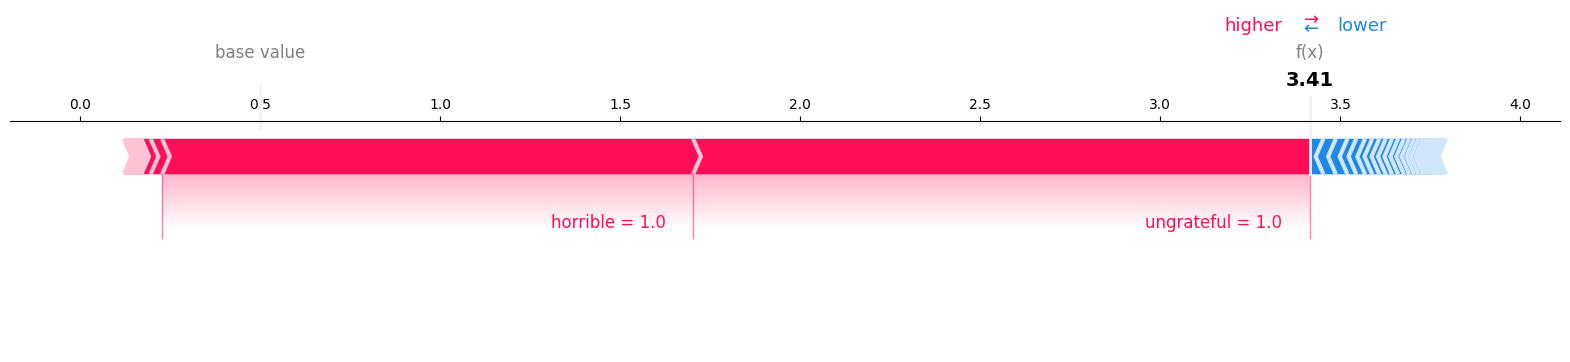


Observation 5:
im feeling more fucked up than ive ever had and its nothing to do with my school work


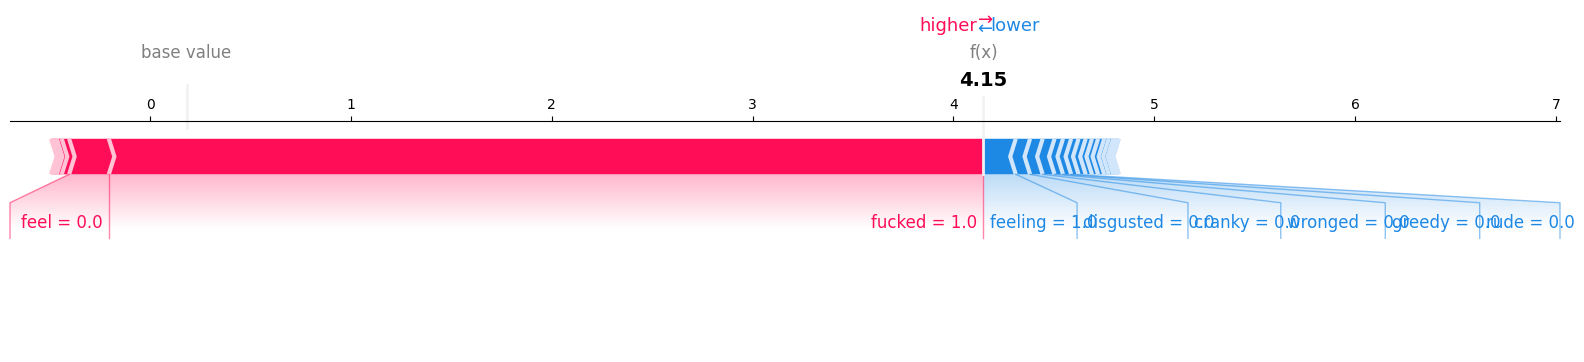

In [59]:
feature_names = vectorizer.get_feature_names_out()


def get_class_shap_vector(shap_values, sample_idx, class_idx):
    if isinstance(shap_values, list):
        return shap_values[class_idx][sample_idx]
    if len(shap_values.shape) == 3:
        return shap_values[sample_idx, :, class_idx]
    raise ValueError(
        f"Unexpected shap_values structure: type={type(shap_values)}, shape={getattr(shap_values, 'shape', None)}"
    )


print("Observation 4:")
print(X_test.iloc[4])
shap_vector = get_class_shap_vector(shap_values, sample_idx=4, class_idx=0)
shap.force_plot(
    explainer.expected_value[0],
    shap_vector,
    X_test_vec[4],
    feature_names=feature_names,
    matplotlib=True,
)

print()
print("Observation 5:")
print(X_test.iloc[5])
shap_vector = get_class_shap_vector(shap_values, sample_idx=5, class_idx=3)
shap.force_plot(
    explainer.expected_value[3],
    shap_vector,
    X_test_vec[5],
    feature_names=feature_names,
    matplotlib=True,
)



## Partie 3 — Défi ouvert : appliquer SHAP par vous-même

Vous disposez maintenant du workflow complet. La dernière étape consiste à l'appliquer de manière autonome sur un jeu de données dont vous pouvez expliquer les variables en langage clair.

### Choisissez un jeu de données

Choisissez un jeu de données dont les variables sont faciles à raisonner et dont la tâche de prédiction peut être discutée de manière responsable.

**Option de démarrage recommandée — Titanic**
```python
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
```

**Autres bonnes options**
- **Maladie cardiaque** : si vous disposez déjà d'un CSV propre ou d'une source locale fiable dans votre environnement
- **Churn client** : variables métier intuitives, adaptées aux explications locales
- **Un jeu de données de votre propre projet** : souvent la meilleure option si vous voulez un transfert direct vers un travail réel

### Vos tâches

Parcourez toutes les étapes ci-dessous. Aucune solution n'est fournie ; utilisez ce que vous avez appris dans les Parties 1 et 2.

**Étape 1 — Charger et explorer**
```python
# Charger le jeu de données
# Vérifier les valeurs manquantes
# Afficher la distribution de la variable cible
# Identifier les variables potentiellement sensibles ou à fort enjeu
```

**Étape 2 — Préparer et entraîner**
```python
# Prétraiter (encoder les variables catégorielles, traiter les valeurs manquantes)
# Découper en train/test
# Entraîner un XGBClassifier
# Évaluer avec classification_report
```

**Étape 3 — Explication SHAP globale**
```python
# Créer un TreeExplainer
# Calculer les valeurs SHAP sur l'ensemble de test
# Tracer le beeswarm summary plot
```
Répondez à ces questions dans une cellule markdown :
- Quelles sont les 3 variables les plus importantes ?
- Pour chacune, une valeur élevée pousse-t-elle vers la classe positive ou contre elle ?
- Le classement correspond-il à votre intuition ou à votre connaissance du domaine ?

**Étape 4 — Explication SHAP locale (3 individus)**
```python
# Choisissez 3 individus de test : un clairement prédit positif, un négatif, un incertain
# Affichez un force plot pour chacun
```
Pour chaque personne, écrivez une phrase expliquant le raisonnement du modèle en langage clair, comme si vous l'expliquiez à un collègue non technique.

**Étape 5 — Vérification d'équité / de risque**
```python
# Identifier les variables sensibles (âge, genre, origine, état de santé, etc.)
# Regarder leur position et leur direction dans le beeswarm plot
```
Écrivez un court paragraphe :
- Le modèle semble-t-il s'appuyer sur des attributs sensibles ou sur des proxys plausibles ?
- Si oui, est-ce justifié dans le contexte, ou potentiellement problématique ?
- Quelle validation supplémentaire voudriez-vous avant d'utiliser ce modèle en pratique ?

### Checklist avant de terminer

- [ ] Le modèle est entraîné et évalué (score F1 rapporté)
- [ ] Le beeswarm est généré et les 3 variables principales sont identifiées
- [ ] 3 force plots avec interprétations en langage clair
- [ ] Vérification d'équité / de risque effectuée avec réflexion écrite
- [ ] Au moins une limite de votre analyse SHAP est notée

## Conclusion — qu'avez-vous appris ?

Revenez au scénario initial : une personne reçoit une décision basée sur un modèle et demande une explication.

Avec les outils de ce notebook, vous devriez maintenant être capable de :
1. Entraîner un modèle haute performance tout en gardant l'interprétabilité dans le workflow
2. Utiliser SHAP pour construire une explication locale pour une prédiction précise
3. Traduire cette explication en langage clair pour une partie prenante ou une personne concernée
4. Auditer les explications globales à la recherche de signaux d'équité et de risque

### La boîte à outils d'interprétabilité — quand utiliser quoi

| Vous voulez savoir... | Utilisez... |
|--------------------|--------|
| Quelles variables comptent le plus, globalement ? | Beeswarm ou diagramme en barres SHAP |
| Comment la valeur d'une variable affecte-t-elle les prédictions ? | Dependence plot SHAP |
| Pourquoi le modèle a-t-il prédit X pour *cette personne précise* ? | Force plot SHAP |
| À quoi ressemble le modèle, simplement ? | Arbre de décision (s'il est assez peu profond) |
| Structure globale rapide des prédictions ? | Biplot ACP (PCA) |

### Pour aller plus loin

- **« Interpretable Machine Learning » de Christoph Molnar** : https://christophm.github.io/interpretable-ml-book/
- **Documentation SHAP** : https://shap.readthedocs.io
- **LIME** : une méthode post hoc alternative à comparer à SHAP
- **Outils d'équité** : `aequitas`, `fairlearn`

> Dernière pensée : l'interprétabilité n'est pas une case à cocher. C'est une pratique qui consiste à comprendre ce qu'un modèle a appris, à le communiquer clairement et à assumer la responsabilité de son impact.
